# SD muons before/after the `HasStation` requirement vs UMD — from YOUR pipeline

This notebook reproduces
`claude_work/revision_asimetrias_sd_umd/02_notebooks/03_sd_vs_umd/comparar_sd_umd`
(Astra), written to be read line by line, and able to run on two sources of input:

| `FUENTE` | SD stations come from | UMD modules come from |
|---|---|---|
| `"insumos_astra"` | Astra's one-off CSV `adst_counts_fast.csv` | your March v11 parquet |
| `"reprocesado_v13"` | **your pipeline**: `ADST_Alexey_module_v13/.../estaciones_sd/` | **your pipeline**: `.../modulos/` |

`insumos_astra` exists only as a check that THIS notebook's code reproduces Astra's
numbers exactly. Once your full run of `Procesamiento_ADST_v17_completo` is done,
switch to `reprocesado_v13`: that is the result obtained entirely with your pipeline.
Both should give the same numbers, because the pilot showed the new tables contain
exactly the same stations, counts and geometry.

**Sign convention: A1 > 0 = early excess, A1 < 0 = late excess.**
Δ = A1(SD) − A1(UMD).

Pandas/numpy/scipy only. No ROOT. Runs in a minute or two, single core.

In [1]:
# Use ONE thread for linear algebra. Not for speed: multi-threaded BLAS can add
# floating-point rounding differences at the 1e-16 level, and we want to compare
# with Astra's numbers bit for bit. Must be set BEFORE importing numpy.
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

import glob
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display, Markdown

In [2]:
# ======================== CONFIGURATION ========================

# "reprocesado_v13" = your own pipeline (the default now that the v13 run exists).
# "insumos_astra"   = Astra's CSV + the v11 parquet, kept as a cross-check of this code.
FUENTE = "reprocesado_v13"

# Folder of this notebook, and the repository root (the folder containing CLAUDE.md).
AQUI = Path(os.path.abspath(""))
REPO = next(p for p in [AQUI, *AQUI.parents] if (p / "CLAUDE.md").is_file())

# Inputs for each FUENTE
CSV_ASTRA = REPO / "claude_work/revision_asimetrias_sd_umd/04_soporte/tablas/adst_counts_fast.csv"
PARQUET_V11 = Path("/home/lsilva/Github/ADST_Alexey_module_v11/parquet_sib_proton_17")
PARQUET_V13 = Path("/home/lsilva/Github/ADST_Alexey_module_v13/parquet_sib_proton_17")

# Astra's published numbers, used only to CHECK this notebook at the end
RESULTADO_ASTRA = REPO / "claude_work/revision_asimetrias_sd_umd/02_notebooks/03_sd_vs_umd/resultados/comparacion_directa.csv"

RESULTADOS = AQUI / "resultados"
RESULTADOS.mkdir(exist_ok=True)

# Binning: identical to your figure SD_Desglose_Componentes_vs_UMD (plots_seccion_6.py)
THETA_MIN, THETA_MAX = 30, 40                          # degrees, [30, 40)
R_EDGES = np.array([150, 300, 450, 600, 750, 900, 1050, 1200, 1350])   # 8 radial bands [m]
R_CENTERS = (R_EDGES[:-1] + R_EDGES[1:]) / 2
PHI_EDGES = np.linspace(-180, 180, 13)                 # 12 azimuth bins of 30 degrees
PHI_CENTERS = (PHI_EDGES[:-1] + PHI_EDGES[1:]) / 2
COS_PHI = np.cos(np.deg2rad(PHI_CENTERS))

# Bootstrap: same as Astra, so the numbers can be compared exactly
N_BOOTSTRAP = 1200
SEMILLA = 20260911

print("FUENTE =", FUENTE)

FUENTE = reprocesado_v13


## 1. Load the inputs into two simple tables

Whatever the source, we build the same two tables with the same column names:

- `sd`  : one row per **SD station per event**, columns
  `source, event_id, sdId, radio, phi_deg, muones, has_sd_rec`
- `umd` : one row per **UMD module**, columns
  `source, event_id, sdId, counterId, radio, phi_deg, muones, has_sd_rec`

where `radio` is the distance to the TRUE shower axis in the shower plane [m] and
`phi_deg` is the shower-plane azimuth in degrees, 0 = early, ±180 = late.

**About φ.** Your pipeline stores `phi_plane_euler_MC_true_core` in radians in [0, 2π)
*with* a historical +π. Your figure undoes it like this (plots_seccion_6.py):

    euler_abs = (degrees(phi) - 180) % 360      # remove the +180, back to [0, 360)
    phi_deg   = (euler_abs + 180) % 360 - 180   # wrap to [-180, 180)

Astra's CSV stored φ directly as `atan2(y, x)` in radians, without the +π, so only a
conversion to degrees is needed. Same angle, two storage conventions.

In [3]:
def phi_pipeline_a_grados(phi_rad_con_mas_pi):
    """Your plots_seccion_6.py conversion: remove the +180 and wrap to [-180, 180)."""
    euler_abs = (np.rad2deg(phi_rad_con_mas_pi) - 180) % 360
    return (euler_abs + 180) % 360 - 180


def leer_carpeta_parquet(carpeta, columnas=None):
    """Read every parquet in a folder, adding `source` = the ROOT file name (like Astra)."""
    partes = []
    for archivo in sorted(Path(carpeta).glob("*.parquet")):
        parte = pd.read_parquet(archivo, columns=columnas)
        parte["source"] = archivo.with_suffix(".root").name
        partes.append(parte)
    if not partes:
        raise FileNotFoundError(f"No hay parquet en {carpeta}")
    return pd.concat(partes, ignore_index=True)


def cargar_umd(carpeta):
    """
    UMD modules from a module-level parquet folder (v11 or v13 `modulos/`).
    Selection = your figure's: Infill UMD counters (counterId >= 100000), 30 <= theta < 40.
    """
    columnas = ["event_id", "counterId", "sdId", "moduleId", "theta_MC",
                "r_core_MC", "phi_plane_euler_MC_true_core", "nMuones_MC"]
    # Does this folder's schema have the new flag? (v13: yes; your old v11: no)
    primer_archivo = next(Path(carpeta).glob("*.parquet"))
    tiene_flag = "has_sd_rec" in pq.read_schema(primer_archivo).names
    df = leer_carpeta_parquet(carpeta, columnas + (["has_sd_rec"] if tiene_flag else []))
    if not tiene_flag:
        df["has_sd_rec"] = True        # v11 only ever contained reconstructed stations
    df = df[(df.counterId >= 100000) & df.theta_MC.between(THETA_MIN, THETA_MAX, inclusive="left")].copy()
    return pd.DataFrame({
        "source": df.source, "event_id": df.event_id.astype(str), "sdId": df.sdId,
        "counterId": df.counterId, "radio": df.r_core_MC,
        "phi_deg": phi_pipeline_a_grados(df.phi_plane_euler_MC_true_core),
        "muones": df.nMuones_MC, "has_sd_rec": df.has_sd_rec.astype(bool),
    })


def cargar_sd_desde_csv_astra(ruta):
    """SD stations from Astra's CSV. Her extraction already applied the cuts below."""
    df = pd.read_csv(ruta, dtype={"event_id": str, "source": str})
    return pd.DataFrame({
        "source": df.source, "event_id": df.event_id, "sdId": df.sdId,
        "radio": df.r, "phi_deg": np.rad2deg(df.phi),
        "muones": df.mu.astype(float), "has_sd_rec": df.has_rec.eq(1),
    })


def cargar_sd_desde_v13(carpeta_estaciones):
    """
    SD stations from your new `estaciones_sd/` tables, with the SAME cuts Astra's
    extraction used, so that both sources describe the same sample:
      30 <= theta < 40, physical Infill SD IDs (2000 < sdId < 90000), 150 <= r < 1800 m.
    """
    df = leer_carpeta_parquet(carpeta_estaciones)
    df = df[df.theta_MC.between(THETA_MIN, THETA_MAX, inclusive="left")
            & (df.sdId > 2000) & (df.sdId < 90000)
            & df.r_core_MC.between(150, 1800, inclusive="left")].copy()
    return pd.DataFrame({
        "source": df.source, "event_id": df.event_id.astype(str), "sdId": df.sdId,
        "radio": df.r_core_MC, "phi_deg": phi_pipeline_a_grados(df.phi_plane_euler_MC_true_core),
        "muones": df.sd_nMuons_MC, "has_sd_rec": df.has_sd_rec.astype(bool),
    })


if FUENTE == "insumos_astra":
    sd = cargar_sd_desde_csv_astra(CSV_ASTRA)
    umd = cargar_umd(PARQUET_V11)
elif FUENTE == "reprocesado_v13":
    sd = cargar_sd_desde_v13(PARQUET_V13 / "estaciones_sd")
    umd = cargar_umd(PARQUET_V13 / "modulos")
else:
    raise ValueError(f"FUENTE desconocida: {FUENTE}")

print(f"SD : {len(sd)} estaciones/evento en {sd.source.nunique()} archivos "
      f"({sd.has_sd_rec.sum()} con SD REC, {(~sd.has_sd_rec).sum()} sin SD REC)")
print(f"UMD: {len(umd)} módulos en {umd.source.nunique()} archivos "
      f"({umd.has_sd_rec.sum()} con SD REC, {(~umd.has_sd_rec).sum()} sin SD REC)")

SD : 106280 estaciones/evento en 20 archivos (51031 con SD REC, 55249 sin SD REC)
UMD: 156903 módulos en 20 archivos (156633 con SD REC, 270 sin SD REC)


## 2. The samples we compare

| Sample | Table | Rows used | Selection |
|---|---|---|---|
| **UMD** | `umd` | modules with `has_sd_rec` | exactly your original curve (your old parquet) |
| **SD before** | `sd` | all stations | no `HasStation` requirement |
| **SD after** | `sd` | stations with `has_sd_rec` | the original requirement |

Plus, only with `reprocesado_v13`, a diagnostic **UMD (all rows)**: including the few
modules the flag added. It shows that change is negligible for the UMD curve.

Two sanity checks before fitting:
- the SD "after" sample must be the same stations as the UMD table deduplicated to
  one row per SD station (both describe reconstructed stations);
- their muon counts cannot be compared the same way (`sd.muones` is the SD tank count,
  `umd.muones` the buried module count), so only the station SETS are compared.

In [4]:
CLAVE_ESTACION = ["source", "event_id", "sdId"]

muestras = {
    "UMD_original": umd[umd.has_sd_rec],
    "SD_antes": sd,
    "SD_despues": sd[sd.has_sd_rec],
}

# Check: SD "after" == stations present in the UMD table (deduplicated), same radius range.
estaciones_umd = (umd[umd.has_sd_rec].drop_duplicates(CLAVE_ESTACION)
                  .query("150 <= radio < 1800")[CLAVE_ESTACION])
estaciones_sd_despues = muestras["SD_despues"][CLAVE_ESTACION]
cruce = estaciones_sd_despues.merge(estaciones_umd, on=CLAVE_ESTACION, how="outer", indicator=True)
iguales = cruce["_merge"].eq("both").all()
print("[{}] SD después == estaciones de la tabla UMD: sólo SD={}, sólo UMD={}".format(
    "PASS" if iguales else "FAIL", int(cruce["_merge"].eq("left_only").sum()),
    int(cruce["_merge"].eq("right_only").sum())))

display(pd.DataFrame([{"muestra": nombre,
                       "filas_150_1350m": int(t.radio.between(150, 1350, inclusive="left").sum()),
                       "archivos": t.source.nunique()} for nombre, t in muestras.items()]))

[PASS] SD después == estaciones de la tabla UMD: sólo SD=0, sólo UMD=0


,muestra,filas_150_1350m,archivos
0,UMD_original,145281,20
1,SD_antes,63398,20
2,SD_despues,48427,20


## 3. The fit — first exactly as in your figure

For one radial band:
1. put each row in one of 12 φ bins;
2. per bin: mean `m` and standard error of the mean `s`;
3. normalise by the average of the 12 means, `M`: `y = m / M`, `e = s / M`;
4. fit `y = 1 + A1 cos φ` with `curve_fit`, weights `sigma = e`, bounds [−2, 2].

This is literally your `plots_seccion_6.py` procedure.

In [5]:
def modelo_armonico(phi_deg, A1):
    return 1 + A1 * np.cos(np.deg2rad(phi_deg))


def ajustar_A1_curve_fit(tabla, r_min, r_max):
    """Your figure's fit, for one radial band. Returns (A1, formal error)."""
    banda = tabla[tabla.radio.between(r_min, r_max, inclusive="left")]
    por_bin = banda.groupby(pd.cut(banda.phi_deg, PHI_EDGES), observed=False)["muones"].agg(["mean", "sem"])
    M = por_bin["mean"].mean()
    popt, pcov = curve_fit(modelo_armonico, PHI_CENTERS, por_bin["mean"] / M,
                           sigma=por_bin["sem"] / M, absolute_sigma=True, bounds=(-2.0, 2.0))
    return popt[0], np.sqrt(pcov[0, 0])


A1_curve_fit = pd.DataFrame(
    {nombre: [ajustar_A1_curve_fit(tabla, lo, hi)[0] for lo, hi in zip(R_EDGES[:-1], R_EDGES[1:])]
     for nombre, tabla in muestras.items()},
    index=[f"{lo}-{hi} m" for lo, hi in zip(R_EDGES[:-1], R_EDGES[1:])])
display(A1_curve_fit.round(4))

,UMD_original,SD_antes,SD_despues
150-300 m,0.0620,0.0331,0.0331
300-450 m,0.0933,0.0602,0.0602
450-600 m,0.0853,0.0588,0.0588
600-750 m,0.1147,0.0605,0.0593
750-900 m,0.1148,0.0576,0.0402
900-1050 m,0.0941,0.0660,-0.0158
1050-1200 m,0.1057,0.0683,-0.0641
1200-1350 m,0.0816,0.0689,-0.1240


## 4. The same fit, written so it can be repeated 1200 times quickly

The bootstrap below refits every band 1200 times. `curve_fit` 1200 × 8 × 3 times is
slow, but this particular fit has an **exact closed-form solution**, so no optimiser
is needed.

We minimise  χ²(A) = Σ_bins [ (y − 1 − A cos φ) / e ]².
Setting dχ²/dA = 0:

$$ A = \frac{\sum \cos\phi\,(y-1)/e^2}{\sum \cos^2\phi / e^2}, \qquad
   \sigma_A = \Big(\sum \cos^2\phi / e^2\Big)^{-1/2} $$

(then clipped to [−2, 2], like the `bounds` of `curve_fit`). It is the same estimator,
not a new model, and we check it against `curve_fit` in every band.

**Moment tables.** To compute a mean and a standard error per bin we only need three
sums over the rows in that bin: the count `n`, the sum `S1` of the values and the sum
`S2` of their squares:

    mean = S1 / n
    SEM² = (S2 − S1²/n) / (n (n − 1))      (= sample variance / n)

So we store those three numbers for every (shower, sample, radial band, φ bin). A
bootstrap replica just re-weights showers and adds the sums up again.

In [6]:
def id_lluvia_padre(event_id):
    """
    Event IDs look like 'Library_...:Run_10000:Shower_1:Use_3'. The same CORSIKA shower
    is re-used several times (Use_1, Use_2, ...) with different cores. Re-uses are NOT
    independent, so the bootstrap must draw whole showers: remove ':Use_N'.
    """
    return event_id.str.replace(r":Use_\d+$", "", regex=True)


# The list of parent showers is built from the SD table (as Astra did). Every UMD row
# must belong to one of them.
lluvias_padre = pd.Index(sorted(id_lluvia_padre(sd.event_id).unique()))
N_LLUVIAS = len(lluvias_padre)
print("Lluvias padre (grupos del bootstrap):", N_LLUVIAS)


def tabla_de_momentos(tabla):
    """
    Array of shape (N_LLUVIAS, 8 bands, 3 moments, 12 phi bins) with, in each cell,
    the moments [n, S1, S2] of the muon counts of the rows of that shower, band, bin.
    """
    t = tabla[tabla.radio.between(150, 1350, inclusive="left")].copy()
    t["banda"] = pd.cut(t.radio, R_EDGES, right=False, labels=False)   # [lo, hi)
    t["bin_phi"] = pd.cut(t.phi_deg, PHI_EDGES, labels=False)         # (lo, hi], as in your figure
    t = t.dropna(subset=["muones", "banda", "bin_phi"])

    indice_lluvia = lluvias_padre.get_indexer(id_lluvia_padre(t.event_id))
    if (indice_lluvia < 0).any():
        raise ValueError("Hay filas cuya lluvia no está en la tabla SD.")

    momentos = np.zeros((N_LLUVIAS, len(R_CENTERS), 3, len(PHI_CENTERS)))
    banda = t.banda.to_numpy(int)
    bin_phi = t.bin_phi.to_numpy(int)
    valores = t.muones.to_numpy(float)
    for k, contribucion in enumerate([np.ones(len(t)), valores, valores**2]):   # n, S1, S2
        np.add.at(momentos, (indice_lluvia, banda, k, bin_phi), contribucion)
    return momentos


def ajustar_desde_momentos(momentos):
    """
    Closed-form fit from summed moments. `momentos` has shape (..., bands, 3, 12 bins);
    any leading dimensions (samples, bootstrap replicas) are kept.
    Returns (A1, sigma_A1) with NaN where the band does not pass the quality rules.
    """
    n, S1, S2 = np.moveaxis(momentos, -2, 0)          # each: (..., bands, 12)
    with np.errstate(divide="ignore", invalid="ignore"):
        media = S1 / n
        sem2 = np.maximum(S2 - S1**2 / n, 0) / (n * (n - 1))
        M = np.nanmean(media, axis=-1, keepdims=True)  # average of the 12 bin means
        y = media / M
        e2 = sem2 / M**2

        # A bin counts only if it has >1 row and a finite, positive error.
        bin_valido = (n > 1) & np.isfinite(y) & np.isfinite(e2) & (e2 > 0)
        peso = np.where(bin_valido, 1 / e2, 0)

        denominador = np.sum(peso * COS_PHI**2, axis=-1)
        numerador = np.sum(np.where(bin_valido, peso * COS_PHI * (y - 1), 0), axis=-1)
        A1 = np.clip(numerador / denominador, -2, 2)
        sigma = np.sqrt(1 / denominador)

        # Quality rules (Astra's): >= 5 valid bins, >= 15 rows, positive mean, error <= 0.5.
        banda_valida = ((bin_valido.sum(axis=-1) >= 5) & (n.sum(axis=-1) >= 15)
                        & (M[..., 0] > 0) & (sigma <= 0.5))
    return np.where(banda_valida, A1, np.nan), np.where(banda_valida, sigma, np.nan)


nombres = list(muestras)
momentos = np.stack([tabla_de_momentos(t) for t in muestras.values()], axis=1)   # (lluvias, muestras, bandas, 3, 12)
A1, sigma_formal = ajustar_desde_momentos(momentos.sum(axis=0))                  # sum over showers

# Check: closed form == curve_fit in all 24 (sample, band) combinations.
diferencia_max = np.nanmax(np.abs(A1 - A1_curve_fit.to_numpy().T))
print("[{}] fórmula cerrada vs curve_fit: máxima diferencia = {:.1e}".format(
    "PASS" if diferencia_max < 1e-7 else "FAIL", diferencia_max))

Lluvias padre (grupos del bootstrap): 960


[PASS] fórmula cerrada vs curve_fit: máxima diferencia = 4.5e-10


## 5. Paired bootstrap over whole showers

UMD, SD before and SD after share the same showers, so their errors are correlated.
The honest uncertainty on the DIFFERENCE Δ = A1(SD) − A1(UMD) comes from redrawing
showers ONCE per replica and refitting all samples with that same draw:

1. draw `N_LLUVIAS` showers with replacement → a weight per shower (how many times drawn);
2. each sample's moments = Σ weight × that shower's moments;
3. refit every band of every sample (closed form).

From the 1200 replicas: bootstrap standard deviation of each A1, percentile 95%
intervals of Δ, and a *simultaneous* 95% band over the 8 radii (the widest standardised
deviation across bands), which protects against picking the most discrepant radius
after looking.

Replicas are drawn in blocks of 40 with a fixed seed: same random numbers as Astra.

In [7]:
def bootstrap_pareado(momentos, n_replicas, semilla):
    rng = np.random.default_rng(semilla)
    momentos_planos = momentos.reshape(N_LLUVIAS, -1)            # one row per shower
    forma_una_replica = momentos.shape[1:]                        # (samples, bands, 3, 12)
    replicas = []
    for inicio in range(0, n_replicas, 40):
        tamano = min(40, n_replicas - inicio)
        pesos = rng.multinomial(N_LLUVIAS, np.full(N_LLUVIAS, 1 / N_LLUVIAS), size=tamano)  # (tamano, lluvias)
        sumados = (pesos @ momentos_planos).reshape(tamano, *forma_una_replica)
        A1_replica, _ = ajustar_desde_momentos(sumados)
        replicas.append(A1_replica)
    return np.concatenate(replicas)                               # (n_replicas, samples, bands)


replicas = bootstrap_pareado(momentos, N_BOOTSTRAP, SEMILLA)
if not np.isfinite(replicas).all():
    print("⚠️  Hay réplicas con A1 = NaN (banda sin calidad suficiente). Revisar antes de interpretar.")

sigma_bootstrap = replicas.std(axis=0, ddof=1)                    # (samples, bands)
i_umd, i_antes, i_despues = nombres.index("UMD_original"), nombres.index("SD_antes"), nombres.index("SD_despues")

delta_antes = A1[i_antes] - A1[i_umd]
delta_despues = A1[i_despues] - A1[i_umd]
replicas_delta_antes = replicas[:, i_antes] - replicas[:, i_umd]
replicas_delta_despues = replicas[:, i_despues] - replicas[:, i_umd]

ic_antes = np.quantile(replicas_delta_antes, [0.025, 0.975], axis=0)
ic_despues = np.quantile(replicas_delta_despues, [0.025, 0.975], axis=0)

# Simultaneous band for the main question (SD before − UMD)
sd_delta_antes = replicas_delta_antes.std(axis=0, ddof=1)
desviacion_max = np.max(np.abs((replicas_delta_antes - replicas_delta_antes.mean(axis=0)) / sd_delta_antes), axis=1)
factor_simultaneo = np.quantile(desviacion_max, 0.95)
banda_sim_baja = delta_antes - factor_simultaneo * sd_delta_antes
banda_sim_alta = delta_antes + factor_simultaneo * sd_delta_antes

resultado = pd.DataFrame({
    "r_min": R_EDGES[:-1], "r_max": R_EDGES[1:], "r_center": R_CENTERS,
    "A_UMD_original": A1[i_umd], "A_SD_antes": A1[i_antes], "A_SD_despues": A1[i_despues],
    "sigma_boot_UMD": sigma_bootstrap[i_umd], "sigma_boot_SD_antes": sigma_bootstrap[i_antes],
    "sigma_boot_SD_despues": sigma_bootstrap[i_despues],
    "delta_antes_menos_UMD": delta_antes, "delta_antes_low95": ic_antes[0], "delta_antes_high95": ic_antes[1],
    "delta_antes_sim_low95": banda_sim_baja, "delta_antes_sim_high95": banda_sim_alta,
    "delta_despues_menos_UMD": delta_despues, "delta_despues_low95": ic_despues[0], "delta_despues_high95": ic_despues[1],
})
resultado.to_csv(RESULTADOS / f"comparacion_directa_{FUENTE}.csv", index=False)
display(resultado.round(4))
print(f"Réplicas: {len(replicas)} | lluvias padre: {N_LLUVIAS} | semilla: {SEMILLA} | factor simultáneo: {factor_simultaneo:.3f}")

,r_min,r_max,r_center,A_UMD_original,A_SD_antes,A_SD_despues,sigma_boot_UMD,sigma_boot_SD_antes,sigma_boot_SD_despues,delta_antes_menos_UMD,delta_antes_low95,delta_antes_high95,delta_antes_sim_low95,delta_antes_sim_high95,delta_despues_menos_UMD,delta_despues_low95,delta_despues_high95
0,150,300,225.0,0.0620,0.0331,0.0331,0.0165,0.0168,0.0168,-0.0288,-0.0410,-0.0164,-0.0455,-0.0122,-0.0288,-0.0410,-0.0164
1,300,450,375.0,0.0933,0.0602,0.0602,0.0089,0.0092,0.0092,-0.0331,-0.0474,-0.0196,-0.0522,-0.0140,-0.0331,-0.0474,-0.0196
2,450,600,525.0,0.0853,0.0588,0.0588,0.0094,0.0098,0.0098,-0.0265,-0.0427,-0.0091,-0.0492,-0.0038,-0.0265,-0.0427,-0.0091
3,600,750,675.0,0.1147,0.0605,0.0593,0.0088,0.0090,0.0090,-0.0543,-0.0742,-0.0347,-0.0811,-0.0274,-0.0554,-0.0753,-0.0355
4,750,900,825.0,0.1148,0.0576,0.0402,0.0110,0.0107,0.0108,-0.0572,-0.0842,-0.0302,-0.0927,-0.0217,-0.0746,-0.1010,-0.0481
5,900,1050,975.0,0.0941,0.0660,-0.0158,0.0139,0.0120,0.0119,-0.0281,-0.0607,0.0063,-0.0729,0.0167,-0.1099,-0.1421,-0.0792
6,1050,1200,1125.0,0.1057,0.0683,-0.0641,0.0190,0.0133,0.0139,-0.0374,-0.0804,0.0050,-0.0971,0.0223,-0.1698,-0.2113,-0.1257
7,1200,1350,1275.0,0.0816,0.0689,-0.1240,0.0344,0.0157,0.0186,-0.0127,-0.0897,0.0555,-0.1110,0.0855,-0.2056,-0.2850,-0.1307


Réplicas: 1200 | lluvias padre: 960 | semilla: 20260911 | factor simultáneo: 2.670


## 6. Did we reproduce Astra's numbers?

Every column of `comparacion_directa.csv` from Astra's notebook vs this notebook.
Expected: identical to ~1e-12 (same inputs or identical reprocessed inputs, same
estimator, same random draws).

In [8]:
astra = pd.read_csv(RESULTADO_ASTRA)
diferencias = (resultado[astra.columns] - astra).abs().max()
tabla_diferencias = diferencias.to_frame("max |nuestro − Astra|")
display(tabla_diferencias)
reproducido = bool((diferencias < 1e-7).all())
print("[{}] Resultado de Astra reproducido con FUENTE={} (tolerancia 1e-7)".format(
    "PASS" if reproducido else "FAIL", FUENTE))

,max |nuestro − Astra|
r_min,0.000000e+00
r_max,0.000000e+00
r_center,0.000000e+00
A_UMD_original,9.714451e-17
A_SD_antes,8.326673e-17
A_SD_despues,8.326673e-17
sigma_boot_UMD,9.714451e-17
sigma_boot_SD_antes,7.632783e-17
sigma_boot_SD_despues,7.285839e-17
delta_antes_menos_UMD,9.020562e-17


[PASS] Resultado de Astra reproducido con FUENTE=reprocesado_v13 (tolerancia 1e-7)


## 7. Diagnostic (only `reprocesado_v13`): does the flag change the UMD curve?

Removing the `HasStation` skip adds a handful of UMD module rows (≈ 2 per file in the
pilot). This refits the UMD curve with ALL modules. Expected: essentially identical.

In [9]:
if FUENTE == "reprocesado_v13":
    A1_umd_todo, _ = ajustar_desde_momentos(tabla_de_momentos(umd).sum(axis=0))
    display(pd.DataFrame({"r_center": R_CENTERS, "A_UMD_has_sd_rec": A1[i_umd],
                          "A_UMD_todas_las_filas": A1_umd_todo,
                          "diferencia": A1_umd_todo - A1[i_umd]}).round(5))
    print("Filas UMD sin SD REC añadidas:", int((~umd.has_sd_rec).sum()))
else:
    print("Sólo aplica a FUENTE='reprocesado_v13' (la tabla v11 no tiene filas sin SD REC).")

,r_center,A_UMD_has_sd_rec,A_UMD_todas_las_filas,diferencia
0,225.0,0.06196,0.06196,0.0
1,375.0,0.09326,0.09326,0.0
2,525.0,0.08530,0.08530,0.0
3,675.0,0.11472,0.11472,0.0
4,825.0,0.11478,0.11478,0.0
5,975.0,0.09410,0.09410,0.0
6,1125.0,0.10567,0.10567,0.0
7,1275.0,0.08160,0.08160,0.0


Filas UMD sin SD REC añadidas: 270


## 8. The figure

Top: the three curves on the same axis (error bars = 1 bootstrap standard deviation).
Bottom: SD − UMD with pointwise 95% intervals; the shaded band is the simultaneous 95%
band for SD before − UMD.

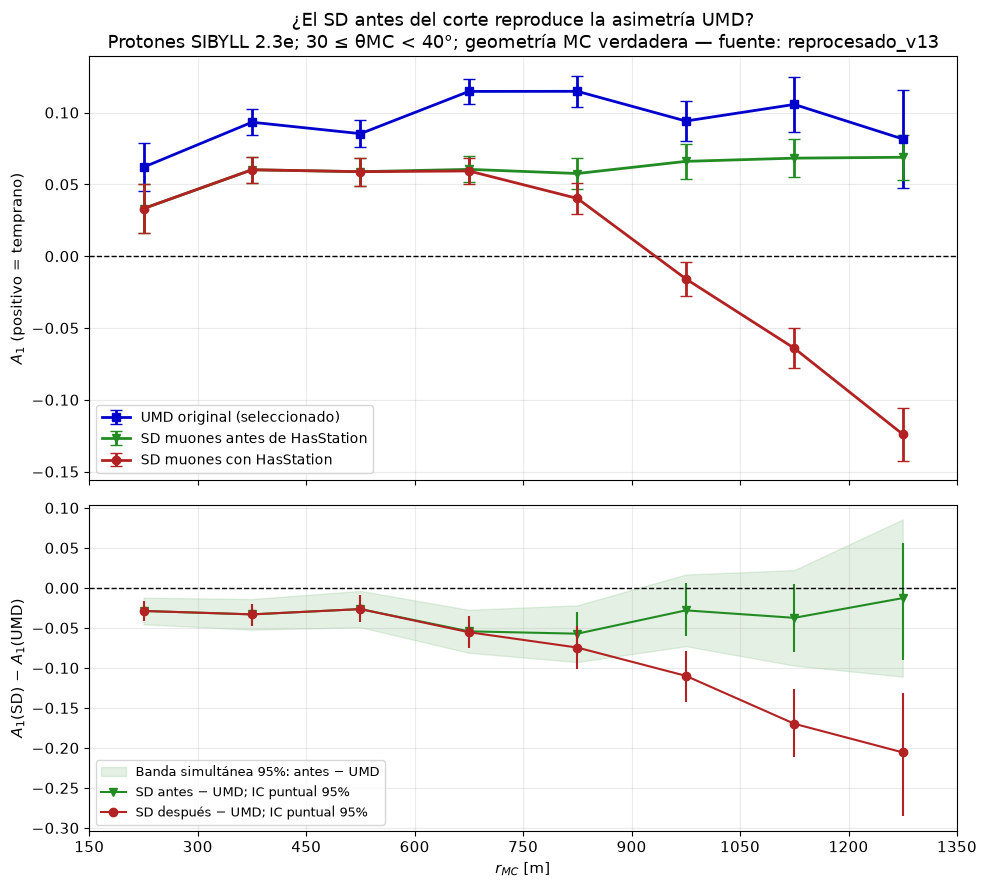

In [10]:
plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.alpha": .25})
fig, (ax, dx) = plt.subplots(2, 1, figsize=(10, 9), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]})

for i, etiqueta, color, marca in [
        (i_umd, "UMD original (seleccionado)", "mediumblue", "s"),
        (i_antes, "SD muones antes de HasStation", "forestgreen", "v"),
        (i_despues, "SD muones con HasStation", "firebrick", "o")]:
    ax.errorbar(R_CENTERS, A1[i], yerr=sigma_bootstrap[i], label=etiqueta,
                color=color, marker=marca, capsize=4, lw=2)
ax.axhline(0, color="black", ls="--", lw=1)
ax.set_ylabel("$A_1$ (positivo = temprano)")
ax.legend(loc="lower left", fontsize=10)
ax.set_title("¿El SD antes del corte reproduce la asimetría UMD?\n"
             f"Protones SIBYLL 2.3e; 30 ≤ θMC < 40°; geometría MC verdadera — fuente: {FUENTE}")

dx.fill_between(R_CENTERS, banda_sim_baja, banda_sim_alta, color="forestgreen", alpha=.12,
                label="Banda simultánea 95%: antes − UMD")
for delta, ic, etiqueta, color, marca in [
        (delta_antes, ic_antes, "SD antes − UMD; IC puntual 95%", "forestgreen", "v"),
        (delta_despues, ic_despues, "SD después − UMD; IC puntual 95%", "firebrick", "o")]:
    dx.plot(R_CENTERS, delta, color=color, marker=marca, label=etiqueta)
    dx.vlines(R_CENTERS, ic[0], ic[1], color=color)
dx.axhline(0, color="black", ls="--", lw=1)
dx.set_ylabel("$A_1$(SD) − $A_1$(UMD)")
dx.set_xlabel("$r_{MC}$ [m]")
dx.set_xticks(R_EDGES)
dx.legend(loc="lower left", fontsize=9)
fig.tight_layout()
fig.savefig(RESULTADOS / f"SD_sin_corte_vs_UMD_{FUENTE}.pdf")
fig.savefig(RESULTADOS / f"SD_sin_corte_vs_UMD_{FUENTE}.png", dpi=170)
plt.show()

## 9. Reading the result (same caveats as Astra's notebook, restated briefly)

- **Shown here:** requiring a reconstructed SD station changes which stations enter the
  SD average, and that alone turns the far-radius SD-muon A1 negative. Removing only that
  requirement brings it back positive.
- **Where to compare with UMD:** at r ≳ 900 m, where the requirement removes most stations,
  look at whether the Δ intervals include 0. At r ≲ 900 m SD before = SD after (almost
  nothing is removed), so any SD − UMD gap there is not caused by this requirement.
- **Not shown:** that SD and UMD must have the same A1. They are different observables
  (tank-crossing count vs buried-module count). The UMD curve is still the selected one:
  Offline does not write UMD truth for SD stations that did not trigger, so an unselected
  UMD curve cannot be built from these files.
- **Scope:** one production (SIBYLL 2.3e protons, 17.5–18), one zenith band. Other bands and
  primaries are the natural next check: the `estaciones_sd/` tables for every production
  already contain what is needed.